# 1. Data Exploration & Preprocessing

This notebook explores the **CIC-DDoS2019** dataset after initial cleaning.  
Goals:
1. Load the preprocessed train/test splits.
2. Inspect feature distributions, class balance, and correlations.
3. Clean column names and remove problematic features.
4. Encode labels for multi-class and binary classification.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
print('Libraries loaded.')

Libraries loaded.


## 1.1 Load Data

We use the preprocessed CSV exports (already cleaned of infinities, NaNs, and
constant columns via the EDA notebooks).

In [ ]:
# --- Adjust paths to your data location ---------------------------------
DATA_DIR = '../data'

X_train = pd.read_csv(f'{DATA_DIR}/preprocessed_train_X.csv')
y_train = pd.read_csv(f'{DATA_DIR}/preprocessed_train_y.csv').squeeze()
X_test  = pd.read_csv(f'{DATA_DIR}/preprocessed_test_X.csv')
y_test  = pd.read_csv(f'{DATA_DIR}/preprocessed_test_y.csv').squeeze()

print(f'Training set : {X_train.shape[0]:,} samples, {X_train.shape[1]} features')
print(f'Test set     : {X_test.shape[0]:,} samples, {X_test.shape[1]} features')

Training set : 97,807 samples, 45 features
Test set     : 24,452 samples, 45 features


## 1.2 Column Cleanup

In [ ]:
# Strip whitespace from column names
X_train.columns = X_train.columns.str.strip()
X_test.columns  = X_test.columns.str.strip()

# Drop known problematic columns (string-valued, causes dtype issues)
for col in ['SimillarHTTP', 'SimilarHTTP']:
    if col in X_train.columns:
        X_train.drop(columns=[col], inplace=True)
        X_test.drop(columns=[col], inplace=True)
        print(f'Dropped column: {col}')

print(f'Features after cleanup: {X_train.shape[1]}')
print(f'Columns: {list(X_train.columns[:10])} ...')

Dropped column: SimillarHTTP
Features after cleanup: 44
Columns: ['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean'] ...


## 1.3 Attack-Type Distribution

In [ ]:
attack_counts = y_train.value_counts()
print(f'Unique attack types: {len(attack_counts)}\n')

for label, count in attack_counts.items():
    pct = count / len(y_train) * 100
    print(f'  {label:<15} : {count:>7,} ({pct:5.1f}%)')

Unique attack types: 13

  BENIGN          :  30,607 ( 31.3%)
  DrDoS_DNS       :   5,600 (  5.7%)
  Portmap         :   5,600 (  5.7%)
  DrDoS_SSDP      :   5,600 (  5.7%)
  DrDoS_SNMP      :   5,600 (  5.7%)
  LDAP            :   5,600 (  5.7%)
  DrDoS_NTP       :   5,600 (  5.7%)
  NetBIOS         :   5,600 (  5.7%)
  UDP             :   5,600 (  5.7%)
  UDP-lag         :   5,600 (  5.7%)
  Syn             :   5,600 (  5.7%)
  MSSQL           :   5,600 (  5.7%)
  TFTP            :   5,600 (  5.7%)


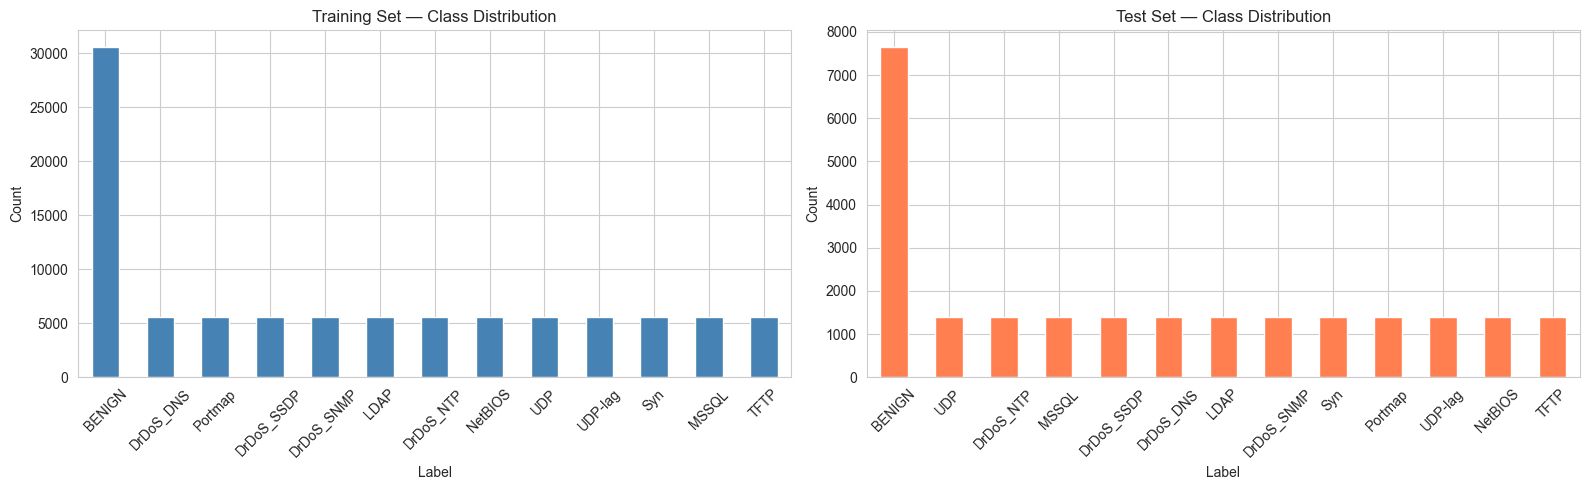

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Training distribution
y_train.value_counts().plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title('Training Set — Class Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Test distribution
y_test.value_counts().plot.bar(ax=axes[1], color='coral')
axes[1].set_title('Test Set — Class Distribution')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../results/figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.4 Feature Statistics

In [ ]:
# Numeric feature summary
exclude_cols = {'Protocol', 'Timestamp', 'timestamp'}
numeric_cols = X_train.select_dtypes(include=[np.number]).columns
feature_cols = [c for c in numeric_cols if c not in exclude_cols]

print(f'Numeric feature columns : {len(feature_cols)}')
print(f'Protocol column present : {"Protocol" in X_train.columns}')
print(f'Timestamp column present: {"Timestamp" in X_train.columns}')

X_train[feature_cols].describe().T.round(3)

Numeric feature columns : 43
Protocol column present : True
Timestamp column present: False


,count,mean,std,min,25%,50%,75%,max
Flow Duration,97807.0,141.270,6.051330e+02,-1.000000e-03,-0.001,0.0,0.999,3.577192e+03
Total Fwd Packets,97807.0,6.124,2.080200e+01,-5.000000e-01,0.000,0.0,1.000,9.900000e+01
Total Length of Fwd Packets,97807.0,2.792,3.294800e+01,-2.430000e-01,-0.227,0.0,0.773,8.107253e+03
Total Length of Bwd Packets,97807.0,367.417,1.781188e+03,0.000000e+00,0.000,0.0,0.000,1.295596e+04
Fwd Packet Length Max,97807.0,0.356,1.169000e+00,-5.280000e-01,-0.514,0.0,0.486,7.348200e+01
Fwd Packet Length Std,97807.0,16.213,5.732100e+01,0.000000e+00,0.000,0.0,0.000,4.020760e+02
Bwd Packet Length Max,97807.0,96.748,4.376310e+02,0.000000e+00,0.000,0.0,0.000,2.896000e+03
Bwd Packet Length Min,97807.0,9.078,2.847900e+01,0.000000e+00,0.000,0.0,0.000,1.590000e+02
Bwd Packet Length Mean,97807.0,28.204,9.851300e+01,0.000000e+00,0.000,0.0,0.000,6.891430e+02
Bwd Packet Length Std,97807.0,28.248,1.449770e+02,0.000000e+00,0.000,0.0,0.000,6.938950e+03


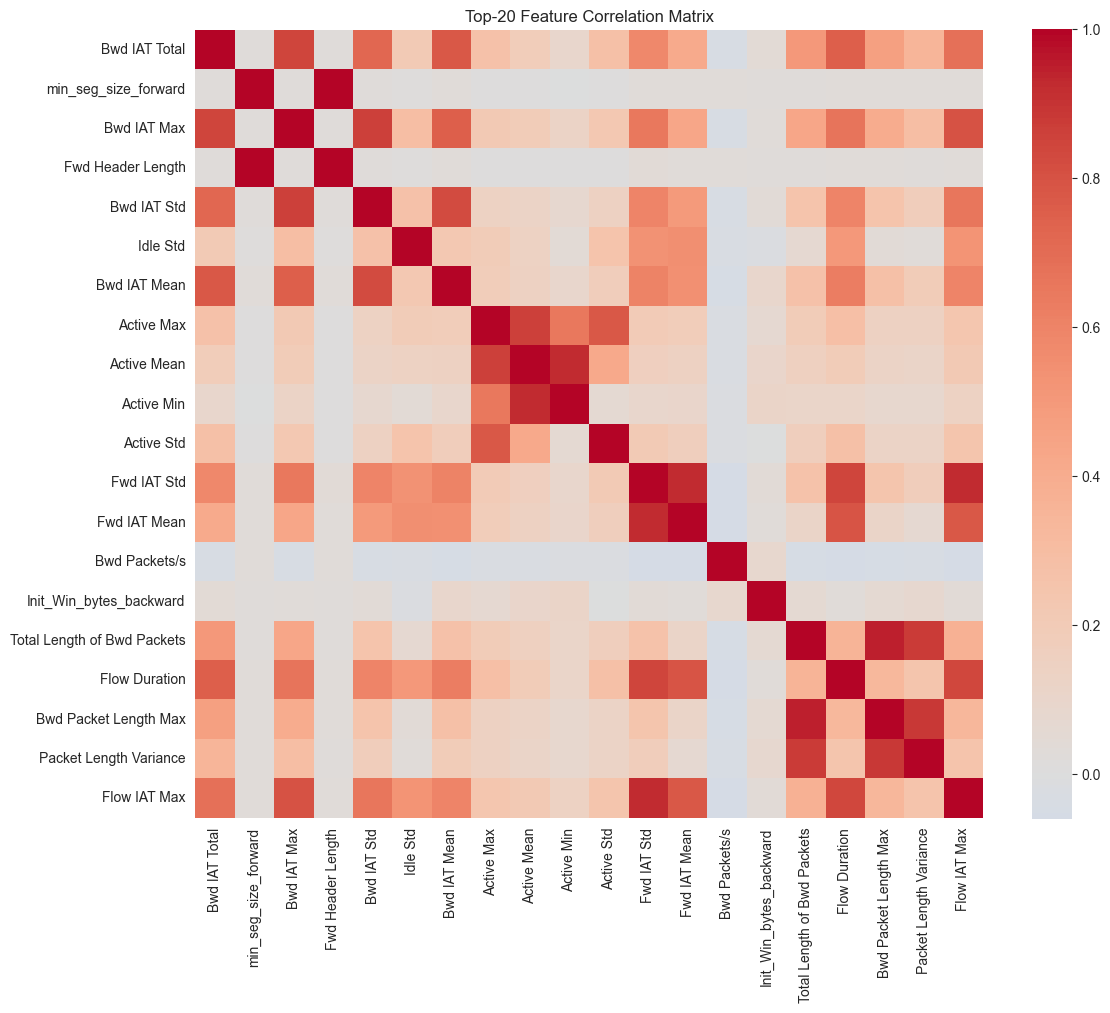

In [ ]:
# Top-20 feature correlation heatmap
top_features = X_train[feature_cols].var().nlargest(20).index.tolist()
corr = X_train[top_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, square=True)
plt.title('Top-20 Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../results/figures/feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.5 Label Encoding

In [ ]:
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded  = label_encoder.transform(y_test)
num_classes = len(label_encoder.classes_)

print(f'Number of classes: {num_classes}')
for i, name in enumerate(label_encoder.classes_):
    count = np.sum(y_train_encoded == i)
    print(f'  {i:2d}: {name:<15} ({count:>6,} samples)')

print(f'\nTrain label distribution: {np.bincount(y_train_encoded)}')
print(f'Test  label distribution: {np.bincount(y_test_encoded)}')

Number of classes: 13
   0: BENIGN          (30,607 samples)
   1: DrDoS_DNS       ( 5,600 samples)
   2: DrDoS_NTP       ( 5,600 samples)
   3: DrDoS_SNMP      ( 5,600 samples)
   4: DrDoS_SSDP      ( 5,600 samples)
   5: LDAP            ( 5,600 samples)
   6: MSSQL           ( 5,600 samples)
   7: NetBIOS         ( 5,600 samples)
   8: Portmap         ( 5,600 samples)
   9: Syn             ( 5,600 samples)
  10: TFTP            ( 5,600 samples)
  11: UDP             ( 5,600 samples)
  12: UDP-lag         ( 5,600 samples)

Train label distribution: [30607  5600  5600  5600  5600  5600  5600  5600  5600  5600  5600  5600
  5600]
Test  label distribution: [7652 1400 1400 1400 1400 1400 1400 1400 1400 1400 1400 1400 1400]


## 1.6 Summary

| Property | Details |
|---|---|
| Features | 43 numeric |
| Classes | 13 (BENIGN + 12 attack types) |
| Protocol column | Yes, used for grouping into sequences |
| Timestamp column | Yes, used for temporal ordering |

**Next step → [02_sequence_creation.ipynb](02_sequence_creation.ipynb):** Convert tabular flows into temporal sequences for transformer input.